**Imports:**

In [2]:
import numpy as np
import pybullet as p
import matplotlib.pyplot as plt
from gym_pybullet_drones.envs.VelocityAviary import VelocityAviary
from gym_pybullet_drones.utils.enums import DroneModel
import time

**Initialize Environment:**

In [3]:
#create environment
# Close any existing environment first
try:
    env.close()
except:
    pass

env = VelocityAviary(
    drone_model=DroneModel.CF2X,
    initial_xyzs=np.array([[0, 0, 1.0]]),
    gui=True  #False for headless mode
)

obs, info = env.reset()
print("Env initialized")
print(f"Observation shape: {obs.shape}")

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
viewMatrix (0.642787516117096, -0.4393851161003113, 0.6275069713592529, 0.0, 0.766044557094574, 0.36868777871131897, -0.5265407562255859, 0.0, -0.0, 0.8191521167755127, 0.5735764503479004, 0.0, 2.384185791015625e-07, 2.384185791015625e-07, -5.000000476837158, 1.0)
projectionMatrix (0.7499999403953552, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, -1.0000200271606445, -1.0, 0.0, 0.0, -0.02000020071864128, 0.0)


c:\Users\Teodora\OneDrive\Documents\GitHub\Thesis\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\Teodora\OneDrive\Documents\GitHub\Thesis\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Env initialized
Observation shape: (1, 20)


**Drone Position as Helper:**

In [4]:
def get_drone_position(obs):
    """
    get drone position from observation
    observation format: [x, y, z, ...]
    """
    return obs[0, :3]  #first 3 elements are position

def print_position(step, obs):
    """
    print current drone position for analysis purposes
    """
    pos = get_drone_position(obs)
    print(f"Step {step:3d}: Position = [{pos[0]:6.3f}, {pos[1]:6.3f}, {pos[2]:6.3f}]")

**1. Try to Make It Hover in Place**

Idea: the drone should be hovering at the initial position.

In [5]:
#reset environment - just in case
obs, info = env.reset()
print("Case 1: hovering in place")

#for now 100 steps (small amount)
for i in range(100):
    #action looks like: [vx, vy, vz, yaw_rate] - should be all zeros for hovering
    action = np.array([[0, 0, 0, 0]])
    obs, reward, terminated, truncated, info = env.step(action)
    
    if i % 20 == 0:
        print_position(i, obs)
    
    if terminated or truncated:
        print("Episode ended early heh, your drone sucks >:]")
        break

print("Hover complete. Slay.")

Case 1: hovering in place
Step   0: Position = [ 0.000,  0.000,  1.000]
Step  20: Position = [ 0.000,  0.000,  1.000]
Step  40: Position = [ 0.000,  0.000,  1.000]
Step  60: Position = [ 0.000,  0.000,  1.000]
Step  80: Position = [ 0.000,  0.000,  1.000]
Hover complete. Slay.


**2. Try Linear Movement**

Idea: move the drone in straight lines along different axes. 
- shoule be able to move forward/backward along x 
- should be able to move left/right along y 

No z. 

=> I am trying to make it go square movement cause it's perfect example of x,y movement

In [6]:
#reset environment - every time we need to do this 
obs, info = env.reset()
print("Case 2: linear movement in x and y")

positions = []
steps_per_direction = 50

#move forward = positive x
print("moving forward:")
for i in range(steps_per_direction):
    action = np.array([[0.5, 0, 0, 0]])  #vx=1
    obs, reward, terminated, truncated, info = env.step(action)
    positions.append(get_drone_position(obs))
    if i % 10 == 0:
        print_position(i, obs)

#move right = positive y
print("moving right:")
for i in range(steps_per_direction):
    action = np.array([[0, 0.5, 0, 0]])  #vy=1
    obs, reward, terminated, truncated, info = env.step(action)
    positions.append(get_drone_position(obs))
    if i % 10 == 0:
        print_position(i, obs)

#move backward = negative x
print("moving backward:")
for i in range(steps_per_direction):
    action = np.array([[-0.5, 0, 0, 0]])  #vx=-1
    obs, reward, terminated, truncated, info = env.step(action)
    positions.append(get_drone_position(obs))
    if i % 10 == 0:
        print_position(i, obs)

#move left = negative y
print("moving left:")
for i in range(steps_per_direction):
    action = np.array([[0, -0.5, 0, 0]])  #vy=-1
    obs, reward, terminated, truncated, info = env.step(action)
    positions.append(get_drone_position(obs))
    if i % 10 == 0:
        print_position(i, obs)

print("Linear movement done without errrors. :]]")

Case 2: linear movement in x and y
moving forward:
Step   0: Position = [ 0.000,  0.000,  1.000]
Step  10: Position = [ 0.000,  0.000,  1.000]
Step  20: Position = [ 0.000,  0.000,  1.000]
Step  30: Position = [ 0.000,  0.000,  1.000]
Step  40: Position = [ 0.000,  0.000,  1.000]
moving right:
Step   0: Position = [ 0.000,  0.000,  1.000]
Step  10: Position = [ 0.000,  0.000,  1.000]
Step  20: Position = [ 0.000,  0.000,  1.000]
Step  30: Position = [ 0.000,  0.000,  1.000]
Step  40: Position = [ 0.000,  0.000,  1.000]
moving backward:
Step   0: Position = [ 0.000,  0.000,  1.000]
Step  10: Position = [ 0.000,  0.000,  1.000]
Step  20: Position = [ 0.000,  0.000,  1.000]
Step  30: Position = [ 0.000,  0.000,  1.000]
Step  40: Position = [ 0.000,  0.000,  1.000]
moving left:
Step   0: Position = [ 0.000,  0.000,  1.000]
Step  10: Position = [ 0.000,  0.000,  1.000]
Step  20: Position = [ 0.000,  0.000,  1.000]
Step  30: Position = [ 0.000,  0.000,  1.000]
Step  40: Position = [ 0.000,  

*Visualization for square movement*

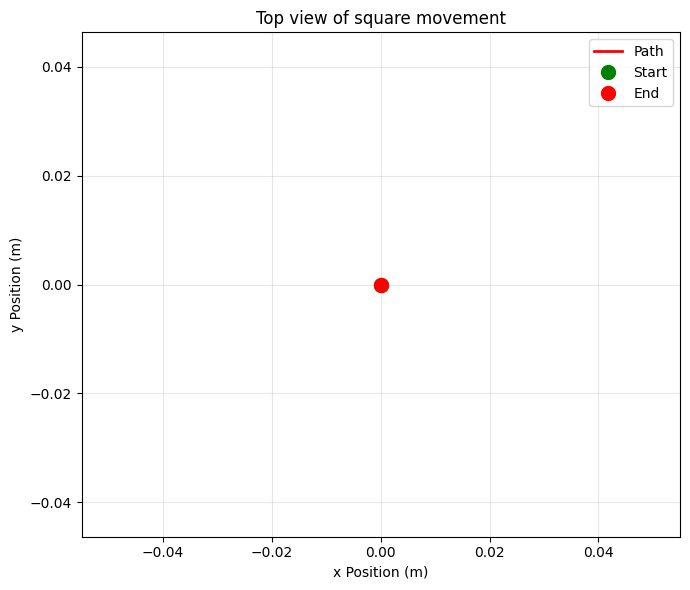

In [7]:
#convert to numpy arrays for plotting
if len(positions) > 0:
    square_pos = np.array(positions)

fig, ax1 = plt.subplots(1, 1, figsize=(7, 6))

#top view for square movement
if len(positions) > 0:
    ax1.plot(square_pos[:, 0], square_pos[:, 1], 'r-', linewidth=2, label='Path')
    ax1.plot(square_pos[0, 0], square_pos[0, 1], 'go', markersize=10, label='Start')
    ax1.plot(square_pos[-1, 0], square_pos[-1, 1], 'ro', markersize=10, label='End')
    ax1.set_xlabel('x Position (m)')
    ax1.set_ylabel('y Position (m)')
    ax1.set_title('Top view of square movement')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.axis('equal')

plt.tight_layout()
plt.show()

**3. Try to Make a Circle**

Idea: make a circular pattern for the drone

In [8]:
obs, info = env.reset()
print("Case 3: make circle")

#this was terminating at the first step so move away from target position first to avoid immediate termination
#apparently HoverAviary terminates when drone is within 0.0001 of [0,0,1] - goal position by default
for i in range(10):
    action = np.array([[0.2, 0, 0, 0]])  #move a bit in x direction
    obs, reward, terminated, truncated, info = env.step(action)

circular_positions = []
radius = 0.3
angular_speed = 0.02

for step in range(300): 
    #calculate circular motion
    vx = radius * np.cos(step * angular_speed)
    vy = radius * np.sin(step * angular_speed)
    
    action = np.array([[vx, vy, 0, 0]])
    obs, reward, terminated, truncated, info = env.step(action)
    circular_positions.append(get_drone_position(obs))
    
    if step % 50 == 0:
        print_position(step, obs)
    
    if terminated or truncated:
        print(f"Episode ended at step {step}: terminated={terminated}, truncated={truncated}")
        break

print(f"Circle done. Collected {len(circular_positions)} positions.")

Case 3: make circle
Step   0: Position = [ 0.000,  0.000,  1.000]
Step  50: Position = [ 0.000,  0.000,  1.000]
Step 100: Position = [ 0.000,  0.000,  1.000]
Step 150: Position = [ 0.000,  0.000,  1.000]
Step 200: Position = [ 0.000,  0.000,  1.000]
Step 250: Position = [ 0.000,  0.000,  1.000]
Circle done. Collected 300 positions.


*Visualization for the last thing, cause I want to see if it works properly or how i can plot this*

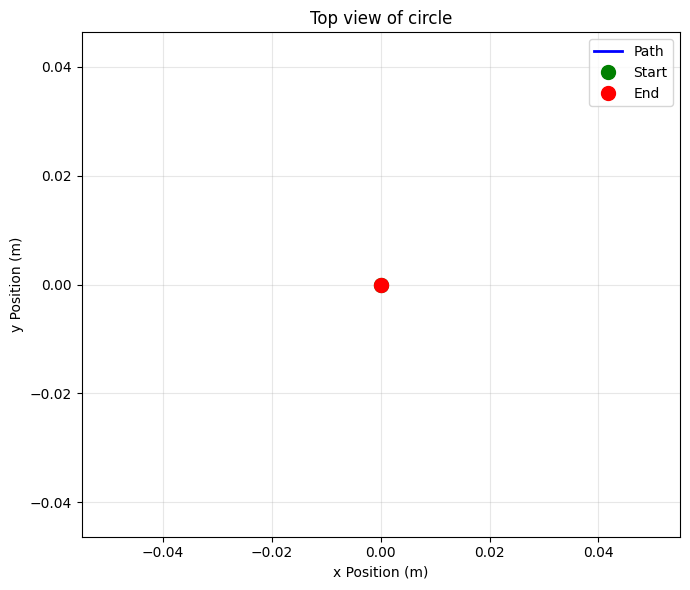

In [9]:
#convert to numpy arrays - I think we need to do this for easier plotting (i do it a lot, but i think it's also possible without?)
if len(circular_positions) > 0:
    circular_pos = np.array(circular_positions)

fig, ax1 = plt.subplots(1, 1, figsize=(7, 6))

#top view for circle
if len(circular_positions) > 0:
    ax1.plot(circular_pos[:, 0], circular_pos[:, 1], 'b-', linewidth=2, label='Path')
    ax1.plot(circular_pos[0, 0], circular_pos[0, 1], 'go', markersize=10, label='Start')
    ax1.plot(circular_pos[-1, 0], circular_pos[-1, 1], 'ro', markersize=10, label='End')
    ax1.set_xlabel('x Position (m)')
    ax1.set_ylabel('y Position (m)')
    ax1.set_title('Top view of circle')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.axis('equal')

plt.tight_layout()
plt.show()

**Close env when done**

In [10]:
env.close()
print("Env closed.")

Env closed.
